# Curse of Dimensionality Assignment

In [10]:
# dependanices
import numpy as np
import matplotlib.pyplot as plt 

In [11]:
# Parameters
max_dim = 100
dims = np.arange(1, max_dim + 1) # dimensions to test

n_points = 20000  # points per trial 
n_trials = 8  # repeat for uncertainty
fixed_radius = 1.5  # fixed neighborhood radius

# Storage for results
frac_fixed = np.zeros((n_trials, max_dim))
frac_scaled = np.zeros((n_trials, max_dim))

median_dist = np.zeros((n_trials, max_dim))
mean_dist = np.zeros((n_trials, max_dim))

for t in range(n_trials):
    rng = np.random.default_rng(42 + t)  # different seed each trial

    for idx, p in enumerate(dims):
        X = rng.standard_normal((n_points, p))
        center = np.ones(p) * fixed_radius  # sigma, so this is the "center" of our neighborhood
        distances = np.linalg.norm(X - center, axis=1)  # distance from center

        frac_fixed[t, idx] = np.mean(distances <= fixed_radius)  # fraction within fixed radius
        scaled_radius = np.sqrt(p)
        frac_scaled[t, idx] = np.mean(distances <= scaled_radius)

        # Distance stats to helps explain the fraction collapse, hopefully
        median_dist[t, idx] = np.median(distances)
        mean_dist[t, idx] = np.mean(distances)

# Summaries across trials for plotting - to show uncertainty bands
# Note the std here is across trials, not across points, since we want to show variability in the estimate of the fraction/median/mean due to random sampling.
fixed_mean = frac_fixed.mean(axis=0)
fixed_std  = frac_fixed.std(axis=0)

scaled_mean = frac_scaled.mean(axis=0)
scaled_std  = frac_scaled.std(axis=0)

med_mean = median_dist.mean(axis=0)
med_std  = median_dist.std(axis=0)

mean_mean = mean_dist.mean(axis=0)
mean_std  = mean_dist.std(axis=0)

# These colors are just for plotting, i like purples
c_fixed  = plt.cm.Purples(0.80)
c_scaled = plt.cm.Purples(0.50)
c_med    = plt.cm.Purples(0.70)
c_mean   = plt.cm.Purples(0.35)



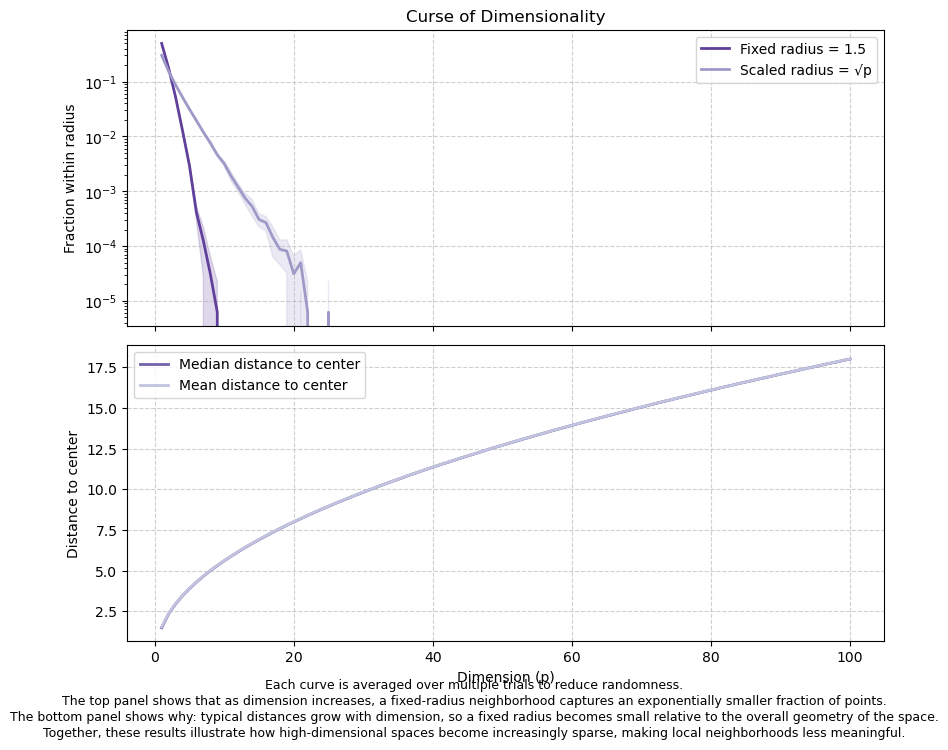

In [12]:
# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 7.5), sharex=True)

# Top: fraction captured vs dimension for fixed vs scaled radius
ax1.plot(dims, fixed_mean, lw=2, color=c_fixed, label=f"Fixed radius = {fixed_radius}")
ax1.fill_between(dims, fixed_mean - fixed_std, fixed_mean + fixed_std, color=c_fixed, alpha=0.2)

ax1.plot(dims, scaled_mean, lw=2, color=c_scaled, label="Scaled radius = √p")
ax1.fill_between(dims, scaled_mean - scaled_std, scaled_mean + scaled_std, color=c_scaled, alpha=0.2)

ax1.set_yscale("log")
ax1.set_ylabel("Fraction within radius")
ax1.set_title("Curse of Dimensionality")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Bottom: typical distance grows with dimension (mean and median)
ax2.plot(dims, med_mean, lw=2, color=c_med, label="Median distance to center")
ax2.fill_between(dims, med_mean - med_std, med_mean + med_std, color=c_med, alpha=0.2)

ax2.plot(dims, mean_mean, lw=2, color=c_mean, label="Mean distance to center")
ax2.fill_between(dims, mean_mean - mean_std, mean_mean + mean_std, color=c_mean, alpha=0.2)

ax2.set_xlabel("Dimension (p)")
ax2.set_ylabel("Distance to center")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

# Caption
fig.text(
    0.5, 0.01,
    "Each curve is averaged over multiple trials to reduce randomness.\n"
    "The top panel shows that as dimension increases, a fixed-radius neighborhood captures an exponentially smaller fraction of points.\n"
    "The bottom panel shows why: typical distances grow with dimension, so a fixed radius becomes small relative to the overall geometry of the space.\n"
    "Together, these results illustrate how high-dimensional spaces become increasingly sparse, making local neighborhoods less meaningful.",
    ha="center", fontsize=9, linespacing=1.3
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("curse_of_dimensionality_LS.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()